In [6]:
import os
import timm
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.nn.functional as nnf
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix, roc_curve, auc, roc_auc_score
from torchvision import models
import torchvision

In [7]:
RANDOM_SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 10
NUM_CLASSES = 3
LAMBDA_PHYS = 0.5
MODEL_PATH = 'resnet_50_pinn_best.pth'

In [8]:
train_dir='../multi-class-classification/dataset/train'
val_dir='../multi-class-classification/dataset/val'

In [9]:
device=('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [10]:
train_imgs = sorted([
    pth for pth in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, pth))
])
val_imgs = sorted([
    pth for pth in os.listdir(val_dir)
    if os.path.isdir(os.path.join(val_dir, pth))
])


In [11]:
train_temp=[]
val_temp=[]

In [12]:
for pth in train_imgs:
    path = os.path.join(train_dir, pth)
    train_temp.append(path)


In [13]:
for pth in val_imgs:
    path = os.path.join(val_dir, pth)
    val_temp.append(path)


In [14]:
train_temp


['../multi-class-classification/dataset/train/no',
 '../multi-class-classification/dataset/train/sphere',
 '../multi-class-classification/dataset/train/vort']

In [15]:
train_img_path=[]
train_class=[]
val_img_path=[]
val_class=[]

In [16]:
CLASS_NAMES = ['no', 'sphere', 'vort']
CLASS_TO_IDX = {label: idx for idx, label in enumerate(CLASS_NAMES)}


def class_def(label):
    return CLASS_TO_IDX[label]


In [17]:
for el in train_temp:
    label_name = os.path.basename(el)
    for it in sorted(os.listdir(el)):
        p = os.path.join(el, it)
        if os.path.isfile(p):
            train_img_path.append(p)
            train_class.append(class_def(label_name))


In [18]:
for el in val_temp:
    label_name = os.path.basename(el)
    for it in sorted(os.listdir(el)):
        p = os.path.join(el, it)
        if os.path.isfile(p):
            val_img_path.append(p)
            val_class.append(class_def(label_name))


In [19]:
train_img_path, test_img_path, train_class, test_class = train_test_split(
    train_img_path,
    train_class,
    test_size=0.1,
    shuffle=True,
    random_state=RANDOM_SEED,
    stratify=train_class,
)


In [20]:
print("Train Size: ", len(train_img_path))
print("Test Size: ", len(test_img_path))
print("Val Size: ", len(val_img_path))

Train Size:  27000
Test Size:  3000
Val Size:  7500


In [21]:
class MyDataset(Dataset):
    def __init__(self, img_path, transform):
        self.img_path = img_path
        self.transform = transform

    def __len__(self):
        return len(self.img_path)

    def __getitem__(self, idx):
        image_path = self.img_path[idx]
        img = np.load(image_path).astype(np.float32)
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        label = os.path.basename(os.path.dirname(image_path))
        label = class_def(label)
        return img, label


In [22]:
def transform(split):
    transforms_list = []
    
    transforms_list.append(transforms.Resize((224, 224)))
    
    if split == 'train':
        transforms_list.append(transforms.RandomHorizontalFlip(p=0.5))
    
    transforms_list.append(transforms.Normalize(mean=[0.449], std=[0.226]))
    return transforms.Compose(transforms_list)

In [23]:
train_transform = transform('train')
val_transform = transform('val')

In [24]:
train_dataset = MyDataset(train_img_path, transform=train_transform)
test_dataset = MyDataset(test_img_path, transform=val_transform)
val_dataset = MyDataset(val_img_path, transform=val_transform)


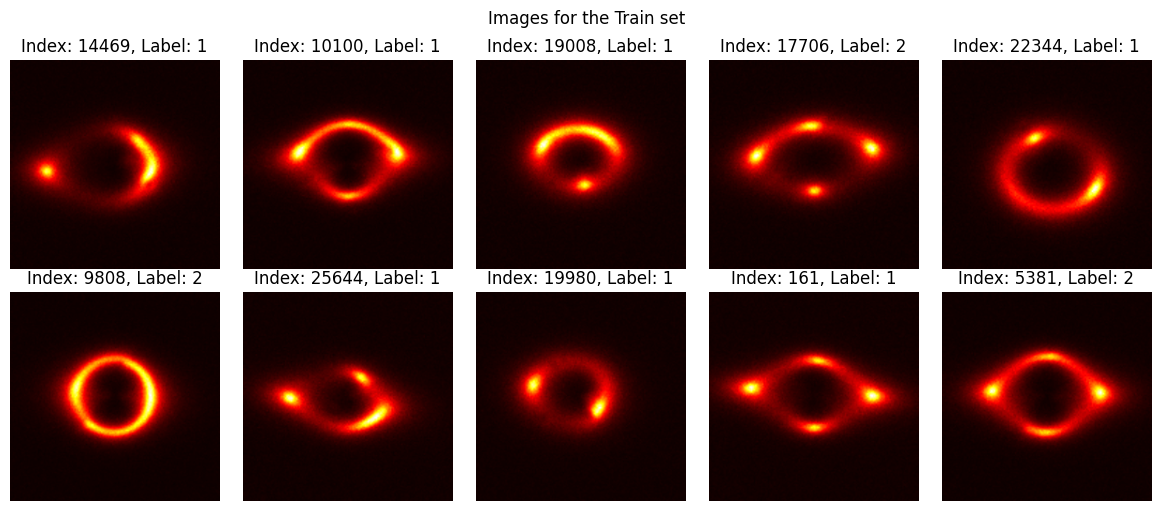

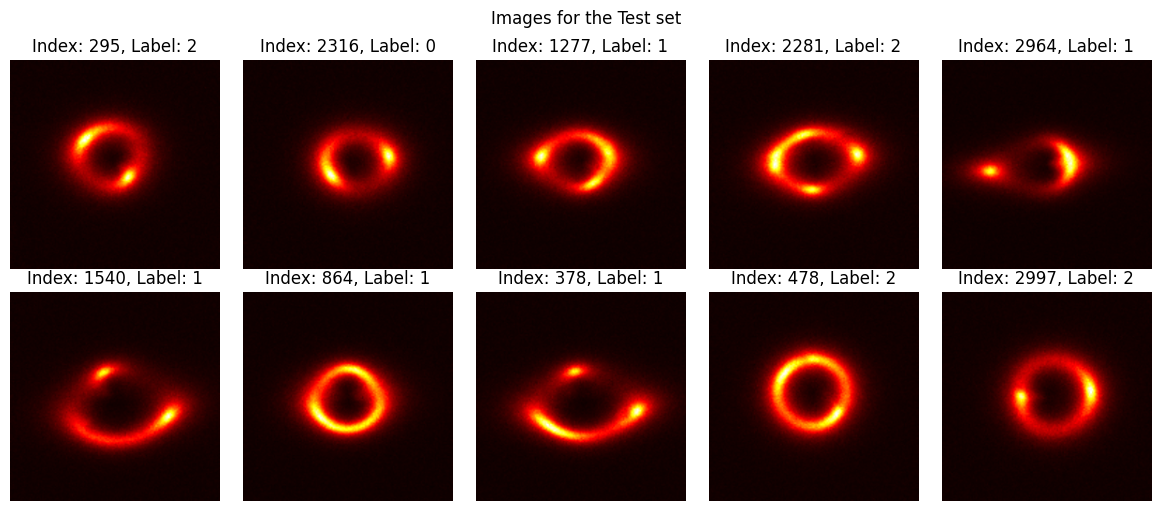

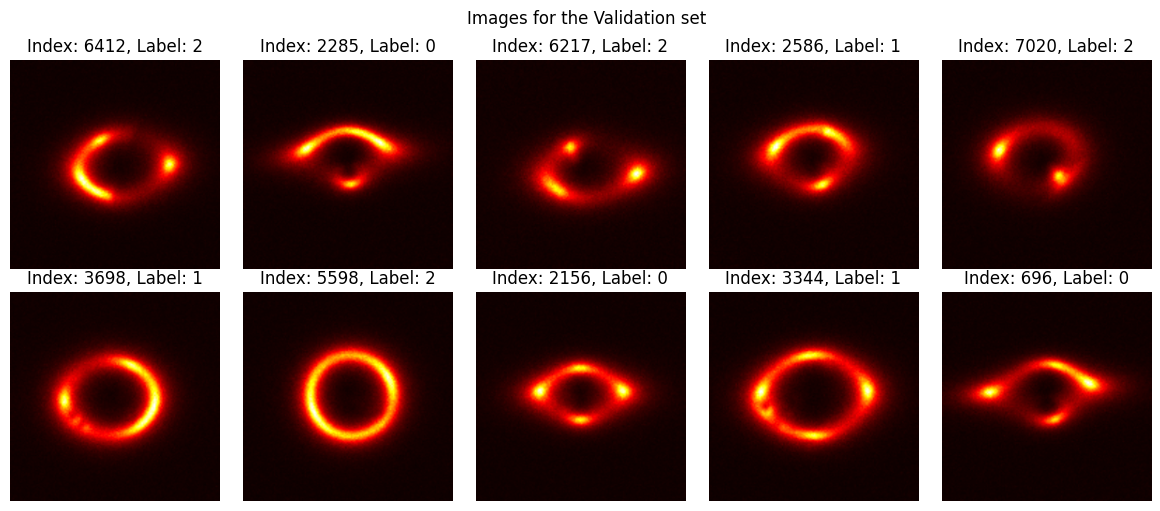

In [25]:
def visualize_images(dataset_input, dataset_type, samples, cols):
    
    dataset_len = len(dataset_input)
    dataset = dataset_input
    
    rows = samples // cols
    
    fig, ax = plt.subplots(nrows = rows, ncols = cols, figsize=(12, 8))
    fig.suptitle(f"Images for the {dataset_type.title()} set", y=0.9)
    
    for i in range(samples):
        idx = np.random.randint(0, dataset_len)
        image, label = dataset[idx]
        image = image.swapaxes(0, 1)
        image = image.swapaxes(1, 2)
        ax.ravel()[i].imshow(image, cmap='hot')
        ax.ravel()[i].set_axis_off()
        ax.ravel()[i].set_title(f"Index: {idx}, Label: {label}")
        
    plt.tight_layout(rect=[0, 0.2, 0.99, 0.975], h_pad=2.1, pad=1.7)
    plt.show()
    
visualize_images(dataset_input=train_dataset, dataset_type="train", samples=10, cols=5)
visualize_images(dataset_input=test_dataset, dataset_type="test", samples=10, cols=5)
visualize_images(dataset_input=val_dataset, dataset_type="validation", samples=10, cols=5)

In [26]:
def MyDataloader(dataset, shuffle):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)
    return loader

In [27]:
train_loader = MyDataloader(dataset=train_dataset, shuffle=True)
test_loader = MyDataloader(dataset=test_dataset, shuffle=False)
val_loader = MyDataloader(dataset=val_dataset, shuffle=False)


## Physics Guided ML

The **thin-lens / SIS deflection angle** is:

$$\vec{\alpha}(\vec{\theta}) = \theta_E^2 \frac{\vec{\theta}}{|\vec{\theta}|^2}$$

For every pixel $(u, v)$ we compute the normalised angular coordinates  
$\theta_x = (u - u_c)/u_c$, $\theta_y = (v - v_c)/v_c$,  
then the deflection magnitude map $|\vec{\alpha}|$ and both components.  
These **three** physics channels are concatenated with the raw image,  
giving a **4-channel** input to the backbone.

In [28]:
class GravitationalLensingLayer(nn.Module):
    def __init__(self, img_size=224, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.log_theta_E = nn.Parameter(torch.zeros(1))
        coords = torch.linspace(-1.0, 1.0, img_size)          
        ty, tx = torch.meshgrid(coords, coords, indexing='ij') 
        self.register_buffer('tx', tx.unsqueeze(0).unsqueeze(0))  
        self.register_buffer('ty', ty.unsqueeze(0).unsqueeze(0))  

    def forward(self, x):
        B = x.shape[0]
        theta_E = self.log_theta_E.exp()                          
        theta_sq = self.tx ** 2 + self.ty ** 2 + self.eps        
        alpha_x = theta_E ** 2 * self.tx / theta_sq              
        alpha_y = theta_E ** 2 * self.ty / theta_sq
        alpha_mag = torch.sqrt(alpha_x ** 2 + alpha_y ** 2 + self.eps)

        def norm_map(t):
            mn, mx = t.min(), t.max()
            return 2.0 * (t - mn) / (mx - mn + self.eps) - 1.0

        alpha_x   = norm_map(alpha_x).expand(B, -1, -1, -1)
        alpha_y   = norm_map(alpha_y).expand(B, -1, -1, -1)
        alpha_mag = norm_map(alpha_mag).expand(B, -1, -1, -1)

        out = torch.cat([x, alpha_x, alpha_y, alpha_mag], dim=1)  
        return out, theta_E

In [29]:
class Model(nn.Module):
    
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.lensing_layer = GravitationalLensingLayer(img_size=IMG_SIZE)
        weights = None
        if pretrained:
            weights = torchvision.models.ResNet50_Weights.DEFAULT

        self.backbone = torchvision.models.resnet50(weights=weights)

        original_conv = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(
            in_channels=4,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=False,
        )
        if pretrained:
            with torch.no_grad():
                self.backbone.conv1.weight.copy_(original_conv.weight.mean(dim=1, keepdim=True))
                for ch in range(1, 4):
                    self.backbone.conv1.weight[:, ch:ch+1, :, :] = (
                        original_conv.weight.mean(dim=1, keepdim=True) * 0.1
                    )
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(in_features, num_classes)
        self.theta_E_head = nn.Linear(in_features, 1)
    def forward(self, x):
        x_phys, theta_E_layer = self.lensing_layer(x) 
        feats = self.backbone(x_phys)
        logits       = self.classifier(feats)             
        theta_E_pred = self.theta_E_head(feats)
        return logits, theta_E_pred, theta_E_layer

In [30]:
def pinn_loss(logits, labels, theta_E_pred, theta_E_layer, lambda_phys=LAMBDA_PHYS):
    ce_loss = nnf.cross_entropy(logits, labels)
    phys_loss = nnf.mse_loss(
        theta_E_pred.squeeze(),
        theta_E_layer.expand(theta_E_pred.shape[0])
    )
    total = ce_loss + lambda_phys * phys_loss
    return total, ce_loss, phys_loss

In [31]:
model=Model(num_classes = NUM_CLASSES, pretrained=True).to(device)

In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
)

In [33]:
best_test_accuracy = 0.0

for ep in range(NUM_EPOCHS):
    model.train()
    print(f'Epoch No.: {ep + 1}')

    total = 0
    correct = 0
    running_loss = 0.0
    ce_total = 0.0
    phys_total = 0.0

    progress_bar = tqdm(train_loader, desc='Train', leave=False)
    for img, lab in progress_bar:
        img = img.to(device)
        lab = lab.to(device)

        optimizer.zero_grad()

        logits, theta_E_pred, theta_E_layer = model(img)
        loss, ce, phys = pinn_loss(logits, lab, theta_E_pred, theta_E_layer)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        _, predicted = torch.max(logits.data, 1)

        batch_size = lab.size(0)
        total += batch_size
        correct += (predicted == lab).sum().item()

        running_loss += loss.item() * batch_size
        ce_total += ce.item() * batch_size
        phys_total += phys.item() * batch_size

        progress_bar.set_postfix(
            loss=f'{running_loss / total:.4f}',
            acc=f'{correct / total:.4f}',
            phys=f'{phys_total / total:.4f}'
        )

    model.eval()
    val_total = 0
    val_correct = 0
    val_loss = 0.0

    with torch.no_grad():
        for img, lab in tqdm(val_loader, desc='Test', leave=False):
            img = img.to(device)
            lab = lab.to(device)

            logits, theta_E_pred, theta_E_layer = model(img)
            loss, _, _ = pinn_loss(logits, lab, theta_E_pred, theta_E_layer)

            _, predicted = torch.max(logits.data, 1)

            batch_size = lab.size(0)
            val_total += batch_size
            val_correct += (predicted == lab).sum().item()
            val_loss += loss.item() * batch_size

    avg_train_loss = running_loss / total
    avg_train_acc = correct / total
    avg_phys_loss = phys_total / total

    avg_test_loss = val_loss / val_total
    avg_test_acc = val_correct / val_total

    scheduler.step(avg_test_loss)

    print(
        f'Train Loss: {avg_train_loss:.4f} '
        f'(CE:{ce_total/total:.4f} Phys:{avg_phys_loss:.4f}) '
        f'Train Acc: {avg_train_acc:.4f} '
        f'Test Loss: {avg_test_loss:.4f} '
        f'Test Acc: {avg_test_acc:.4f} '
        f'LR: {optimizer.param_groups[0]["lr"]:.6f}'
    )

    if avg_test_acc > best_test_accuracy:
        best_test_accuracy = avg_test_acc
        torch.save(model.state_dict(), MODEL_PATH)

print(f'Best Test Accuracy: {best_test_accuracy:.4f}')

Epoch No.: 1


Train Loss: 0.7911 (CE:0.7879 Phys:0.0065) Train Acc: 0.6124 Test Loss: 0.4507 Test Acc: 0.8264 LR: 0.000100
Epoch No.: 2


Train Loss: 0.4052 (CE:0.4041 Phys:0.0022) Train Acc: 0.8468 Test Loss: 0.3263 Test Acc: 0.8825 LR: 0.000100
Epoch No.: 3


Train Loss: 0.3175 (CE:0.3168 Phys:0.0014) Train Acc: 0.8873 Test Loss: 0.3146 Test Acc: 0.8931 LR: 0.000100
Epoch No.: 4


Train Loss: 0.2709 (CE:0.2702 Phys:0.0015) Train Acc: 0.9069 Test Loss: 0.2927 Test Acc: 0.9032 LR: 0.000100
Epoch No.: 5


...

Train Loss: 0.2233 (CE:0.2227 Phys:0.0012) Train Acc: 0.9254 Test Loss: 0.2560 Test Acc: 0.9161 LR: 0.000100
Epoch No.: 7


Train Loss: 0.2070 (CE:0.2066 Phys:0.0008) Train Acc: 0.9318 Test Loss: 0.2261 Test Acc: 0.9284 LR: 0.000100
Epoch No.: 8


Train Loss: 0.1891 (CE:0.1888 Phys:0.0006) Train Acc: 0.9379 Test Loss: 0.2492 Test Acc: 0.9303 LR: 0.000100
Epoch No.: 9


Train Loss: 0.1849 (CE:0.1846 Phys:0.0006) Train Acc: 0.9400 Test Loss: 0.2418 Test Acc: 0.9243 LR: 0.000100
Epoch No.: 10


Train Loss: 0.1724 (CE:0.1722 Phys:0.0005) Train Acc: 0.9447 Test Loss: 0.2562 Test Acc: 0.9283 LR: 0.000050
Best Test Accuracy: 0.9303


In [34]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

total = 0
correct = 0
total_loss = 0.0
phys_total = 0.0
y_test_all = []
y_pred_all = []
y_pred_prob_all = []

with torch.no_grad():
    for img, lab in tqdm(test_loader, desc='Test', leave=False):
        img = img.to(device)
        lab = lab.to(device)

        logits, theta_E_pred, theta_E_layer = model(img)

        prob = nnf.softmax(logits, dim=1)
        _, predicted = torch.max(logits.data, 1)

        y_test_all.append(lab.cpu())
        y_pred_prob_all.append(prob.cpu())
        y_pred_all.append(predicted.cpu())

        total += lab.size(0)
        correct += (predicted == lab).sum().item()
        total_loss += loss.item() * lab.size(0)
        phys_total += phys.item() * lab.size(0)

avg_loss = total_loss / total
avg_phys = phys_total / total
accuracy = 100 * correct / total
print(f'Test Accuracy is: {accuracy:.2f}%')
print(f'Test Loss: {avg_loss:.4f} | Physics Loss: {avg_phys:.4f}')

Test Accuracy is: 92.73%
Test Loss: 0.7400 | Physics Loss: 0.0002


In [35]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

total = 0
correct = 0
total_loss = 0.0
phys_total = 0.0
y_test_all = []
y_pred_all = []
y_pred_prob_all = []

with torch.no_grad():
    for img, lab in tqdm(val_loader, desc='Validation', leave=False):
        img = img.to(device)
        lab = lab.to(device)

        logits, theta_E_pred, theta_E_layer = model(img)

        prob = nnf.softmax(logits, dim=1)
        _, predicted = torch.max(logits.data, 1)

        y_test_all.append(lab.cpu())
        y_pred_prob_all.append(prob.cpu())
        y_pred_all.append(predicted.cpu())

        total += lab.size(0)
        correct += (predicted == lab).sum().item()
        total_loss += loss.item() * lab.size(0)
        phys_total += phys.item() * lab.size(0)

avg_loss = total_loss / total
avg_phys = phys_total / total
accuracy = 100 * correct / total
print(f'Test Accuracy is: {accuracy:.2f}%')
print(f'Test Loss: {avg_loss:.4f} | Physics Loss: {avg_phys:.4f}')

Test Accuracy is: 93.03%
Test Loss: 0.7400 | Physics Loss: 0.0002


In [36]:
y_pred = []
y_test = []
for el in y_test_all:
    y_test.extend(el.detach().numpy().tolist())

for el in y_pred_all:
    y_pred.extend(el.detach().numpy().tolist())


In [37]:
y_prob = []
for el in y_pred_prob_all:
    y_prob.extend(el.detach().numpy().tolist())


In [38]:
y_pred=np.array(y_pred)
y_test=np.array(y_test)
y_pred=y_pred.ravel()
y_test=y_test.ravel()

In [39]:
y_prob=np.array(y_prob)

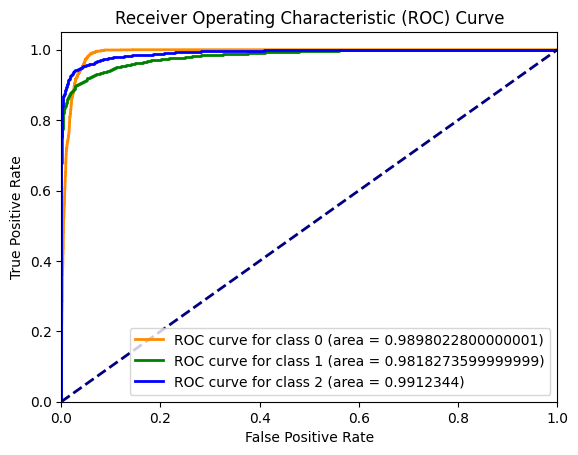

In [40]:
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve((y_test == i), y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
lw = 2
colors = ['darkorange', 'green', 'blue']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw, label=f'ROC curve for class {i} (area = {roc_auc[i]})')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [41]:
for i in range(3):
    print(f"AUC for class {i}: {roc_auc[i]}")

AUC for class 0: 0.9898022800000001
AUC for class 1: 0.9818273599999999
AUC for class 2: 0.9912344


In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94      2500
           1       0.94      0.90      0.92      2500
           2       0.97      0.90      0.94      2500

    accuracy                           0.93      7500
   macro avg       0.93      0.93      0.93      7500
weighted avg       0.93      0.93      0.93      7500

